In [1]:
##imports y rutas
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_curve,
    auc,
    roc_auc_score
)

RANDOM_STATE = 42

PROJECT_ROOT = Path("..").resolve() if Path.cwd().name == "notebooks" else Path(".").resolve()

DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
DOCS_DIR = PROJECT_ROOT / "docs"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)

DATASET_SCALED_PATH = DATA_DIR / "dataset_scaled.csv"
DATASET_ORIGINAL_PATH = DATA_DIR / "dataset.csv"

RF_MODEL_PATH = MODELS_DIR / "rf_model.pkl"
LABEL_ENCODER_PATH = MODELS_DIR / "label_encoder.pkl"

CONFUSION_MATRIX_EVAL_PATH = FIGURES_DIR / "rf_confusion_matrix_eval.png"
CONFUSION_MATRIX_NORMALIZED_PATH = FIGURES_DIR / "rf_confusion_matrix_normalized.png"
ROC_CURVES_PATH = FIGURES_DIR / "rf_roc_curves_ovr.png"
MODEL_COMPARISON_PATH = FIGURES_DIR / "rf_vs_decision_tree_comparison.png"

MISCLASSIFIED_PATH = DATA_DIR / "rf_misclassified_flows.csv"
MODEL_EVALUATION_DOC_PATH = DOCS_DIR / "model_evaluation.md"
MODEL_EVALUATION_JSON_PATH = DOCS_DIR / "model_evaluation_metrics.json"

print("Project root:", PROJECT_ROOT)
print("Dataset exists:", DATASET_SCALED_PATH.exists())
print("RF model exists:", RF_MODEL_PATH.exists())
print("Label encoder exists:", LABEL_ENCODER_PATH.exists())

Project root: /home/angel/projects/CNC_Project
Dataset exists: True
RF model exists: True
Label encoder exists: True


In [2]:
#cargar dataset, modelo y encoder
df_scaled = pd.read_csv(DATASET_SCALED_PATH)

if DATASET_ORIGINAL_PATH.exists():
    df_original = pd.read_csv(DATASET_ORIGINAL_PATH)
else:
    df_original = df_scaled.copy()

rf_model = joblib.load(RF_MODEL_PATH)
label_encoder = joblib.load(LABEL_ENCODER_PATH)

print("Scaled dataset shape:", df_scaled.shape)
print("Original dataset shape:", df_original.shape)
print("Loaded classes:", list(label_encoder.classes_))

display(df_scaled.head())

Scaled dataset shape: (491, 29)
Original dataset shape: (491, 29)
Loaded classes: ['icmp_flood', 'normal', 'port_sweep', 'syn_scan', 'udp_scan']


,protocol,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,dst2src_packets,src2dst_bytes,dst2src_bytes,bidirectional_mean_ps,bidirectional_syn_packets,bidirectional_ack_packets,...,iat_mean_ms_missing,iat_std_ms_missing,iat_cv_missing,rtt_estimate_ms_missing,tcp_window_min_missing,tcp_window_max_missing,tcp_window_mean_missing,tcp_window_var_missing,syn_ack_ratio_manual_missing,label
0,0.996000,-0.549898,-1.258654,-1.391128,-1.221632,-1.078608,-1.221632,-1.253347,-1.074015,-1.074015,...,1.258654,1.258654,1.258654,0.499363,1.074015,1.074015,1.074015,1.074015,1.074015,udp_scan
1,-0.869255,1.818521,0.794499,1.229215,0.818577,1.545013,0.818577,1.265758,0.931085,0.931085,...,-0.794499,-0.794499,-0.794499,-2.002549,-0.931085,-0.931085,-0.931085,-0.931085,-0.931085,normal
2,0.996000,-0.549898,-1.258654,-1.391128,-1.221632,-1.078608,-1.221632,-1.253347,-1.074015,-1.074015,...,1.258654,1.258654,1.258654,0.499363,1.074015,1.074015,1.074015,1.074015,1.074015,udp_scan
3,0.996000,-0.549898,-1.258654,-1.391128,-1.221632,-1.078608,-1.221632,-1.253347,-1.074015,-1.074015,...,1.258654,1.258654,1.258654,0.499363,1.074015,1.074015,1.074015,1.074015,1.074015,udp_scan
4,0.996000,-0.549898,-1.258654,-1.391128,-1.221632,-1.078608,-1.221632,-1.253347,-1.074015,-1.074015,...,1.258654,1.258654,1.258654,0.499363,1.074015,1.074015,1.074015,1.074015,1.074015,udp_scan


In [3]:
##reconstruir X e Y como en el día 2
LABEL_COL = "label"

non_feature_cols = {
    "label",
    "cluster",
    "flow_id",
    "id",
    "src_ip",
    "dst_ip",
    "src_port",
    "dst_port",
    "application_name",
    "application_category_name",
    "requested_server_name",
    "client_fingerprint",
    "server_fingerprint",
    "user_agent",
    "content_type",
    "pcap_file",
    "pcap_path",
    "filename",
    "timestamp",
    "bidirectional_first_seen_ms",
    "bidirectional_last_seen_ms",
}

numeric_cols = df_scaled.select_dtypes(include=[np.number]).columns.tolist()

feature_cols = [
    col for col in numeric_cols
    if col not in non_feature_cols
]

X = df_scaled[feature_cols].copy()
y_raw = df_scaled[LABEL_COL].copy()
y = label_encoder.transform(y_raw)

print("Number of features:", len(feature_cols))
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
for col in feature_cols:
    print("-", col)

print("\nLabel distribution:")
label_distribution = pd.DataFrame({
    "count": y_raw.value_counts(),
    "percentage": y_raw.value_counts(normalize=True).mul(100).round(2)
})
display(label_distribution)

print("Any NaN?", X.isna().any().any())
print("Any inf?", np.isinf(X.to_numpy()).any())

Number of features: 28
X shape: (491, 28)
y shape: (491,)

Features:
- protocol
- bidirectional_duration_ms
- bidirectional_packets
- bidirectional_bytes
- dst2src_packets
- src2dst_bytes
- dst2src_bytes
- bidirectional_mean_ps
- bidirectional_syn_packets
- bidirectional_ack_packets
- bidirectional_rst_packets
- bytes_asymmetry_ratio
- packets_asymmetry_ratio
- bidirectional_packets_per_ms
- bytes_per_packet
- manual_packet_count
- iat_mean_ms
- duration_zero_flag
- syn_ack_ratio_nfstream_missing
- iat_mean_ms_missing
- iat_std_ms_missing
- iat_cv_missing
- rtt_estimate_ms_missing
- tcp_window_min_missing
- tcp_window_max_missing
- tcp_window_mean_missing
- tcp_window_var_missing
- syn_ack_ratio_manual_missing

Label distribution:


,count,percentage
label,,
udp_scan,129,26.27
normal,129,26.27
syn_scan,129,26.27
icmp_flood,61,12.42
port_sweep,43,8.76


Any NaN? False
Any inf? False


In [4]:
##rehacer el mismo train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

train_distribution = pd.Series(
    label_encoder.inverse_transform(y_train),
    name="label"
).value_counts().sort_index()

test_distribution = pd.Series(
    label_encoder.inverse_transform(y_test),
    name="label"
).value_counts().sort_index()

split_distribution = pd.DataFrame({
    "train_count": train_distribution,
    "test_count": test_distribution
})

display(split_distribution)

,train_count,test_count
label,,
icmp_flood,49,12
normal,103,26
port_sweep,34,9
syn_scan,103,26
udp_scan,103,26


In [5]:
##accuracy train/test y overfitting
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
accuracy_gap = train_accuracy - test_accuracy

print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Test accuracy:  {test_accuracy:.4f}")
print(f"Accuracy gap:   {accuracy_gap:.4f}")

if accuracy_gap > 0.05:
    print("Warning: gap > 5%. Possible overfitting. Consider limiting max_depth.")
else:
    print("OK: gap <= 5%. No strong overfitting signal.")

Train accuracy: 0.9796
Test accuracy:  0.9697
Accuracy gap:   0.0099
OK: gap <= 5%. No strong overfitting signal.


In [6]:
##métricas por clase
target_names = label_encoder.classes_

report_dict = classification_report(
    y_test,
    y_test_pred,
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

report_text = classification_report(
    y_test,
    y_test_pred,
    target_names=target_names,
    zero_division=0
)

print(report_text)

report_df = pd.DataFrame(report_dict).T
display(report_df.round(4))

              precision    recall  f1-score   support

  icmp_flood       0.92      1.00      0.96        12
      normal       1.00      0.96      0.98        26
  port_sweep       1.00      0.78      0.88         9
    syn_scan       0.93      1.00      0.96        26
    udp_scan       1.00      1.00      1.00        26

    accuracy                           0.97        99
   macro avg       0.97      0.95      0.96        99
weighted avg       0.97      0.97      0.97        99



,precision,recall,f1-score,support
icmp_flood,0.9231,1.0000,0.9600,12.0000
normal,1.0000,0.9615,0.9804,26.0000
port_sweep,1.0000,0.7778,0.8750,9.0000
syn_scan,0.9286,1.0000,0.9630,26.0000
udp_scan,1.0000,1.0000,1.0000,26.0000
accuracy,0.9697,0.9697,0.9697,0.9697
macro avg,0.9703,0.9479,0.9557,99.0000
weighted avg,0.9719,0.9697,0.9689,99.0000


In [7]:
##comparación con umbrales de calidad del apéndice C
per_class_df = report_df.loc[target_names, ["precision", "recall", "f1-score", "support"]].copy()

per_class_df["quality_against_threshold"] = np.where(
    per_class_df["f1-score"] >= 0.88,
    "excellent",
    np.where(per_class_df["f1-score"] >= 0.80, "acceptable", "needs improvement")
)

display(per_class_df.round(4))

,precision,recall,f1-score,support,quality_against_threshold
icmp_flood,0.9231,1.0000,0.9600,12.0,excellent
normal,1.0000,0.9615,0.9804,26.0,excellent
port_sweep,1.0000,0.7778,0.8750,9.0,acceptable
syn_scan,0.9286,1.0000,0.9630,26.0,excellent
udp_scan,1.0000,1.0000,1.0000,26.0,excellent


,icmp_flood,normal,port_sweep,syn_scan,udp_scan
icmp_flood,12,0,0,0,0
normal,1,25,0,0,0
port_sweep,0,0,7,2,0
syn_scan,0,0,0,26,0
udp_scan,0,0,0,0,26


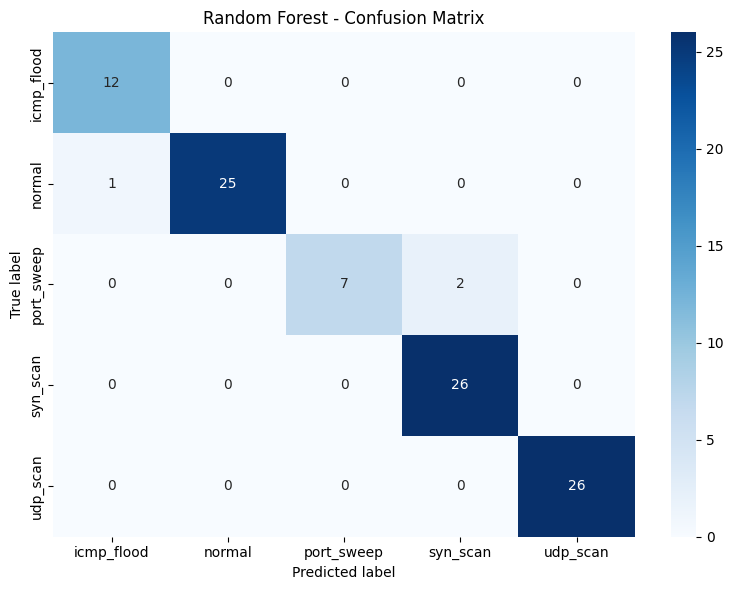

Saved: /home/angel/projects/CNC_Project/reports/figures/rf_confusion_matrix_eval.png


In [8]:
##matriz de confusión absoluta
cm = confusion_matrix(y_test, y_test_pred)

cm_df = pd.DataFrame(
    cm,
    index=target_names,
    columns=target_names
)

display(cm_df)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_EVAL_PATH, dpi=300)
plt.show()

print("Saved:", CONFUSION_MATRIX_EVAL_PATH)

,icmp_flood,normal,port_sweep,syn_scan,udp_scan
icmp_flood,1.0000,0.0000,0.0000,0.0000,0.0
normal,0.0385,0.9615,0.0000,0.0000,0.0
port_sweep,0.0000,0.0000,0.7778,0.2222,0.0
syn_scan,0.0000,0.0000,0.0000,1.0000,0.0
udp_scan,0.0000,0.0000,0.0000,0.0000,1.0


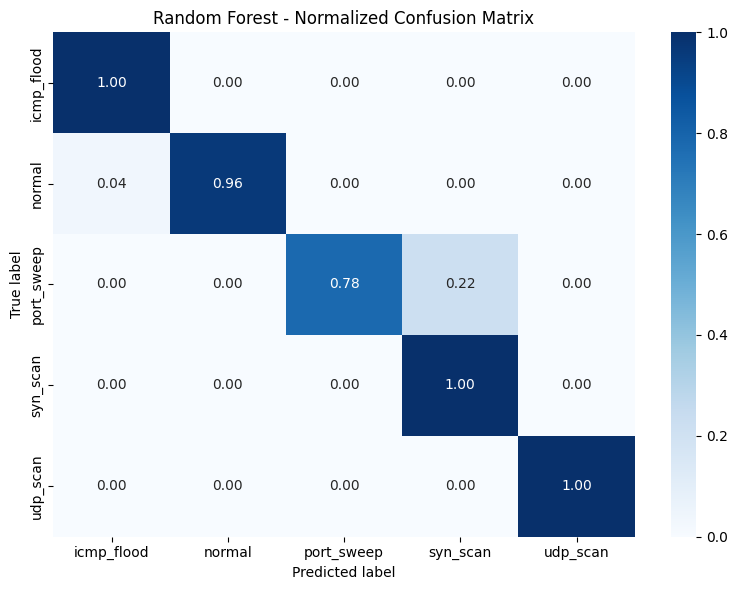

Saved: /home/angel/projects/CNC_Project/reports/figures/rf_confusion_matrix_normalized.png


In [9]:
##matriz de confusión normalizada
cm_normalized = confusion_matrix(
    y_test,
    y_test_pred,
    normalize="true"
)

cm_normalized_df = pd.DataFrame(
    cm_normalized,
    index=target_names,
    columns=target_names
)

display(cm_normalized_df.round(4))

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized_df,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=True
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Random Forest - Normalized Confusion Matrix")
plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_NORMALIZED_PATH, dpi=300)
plt.show()

print("Saved:", CONFUSION_MATRIX_NORMALIZED_PATH)

In [10]:
##extraer errores del modelo
test_results = df_original.iloc[X_test.index].copy()

test_results["true_label"] = label_encoder.inverse_transform(y_test)
test_results["predicted_label"] = label_encoder.inverse_transform(y_test_pred)
test_results["is_correct"] = test_results["true_label"] == test_results["predicted_label"]

misclassified = test_results[~test_results["is_correct"]].copy()

print("Total test samples:", len(test_results))
print("Misclassified samples:", len(misclassified))

display(
    misclassified[
        ["true_label", "predicted_label"] + 
        [col for col in [
            "protocol",
            "bidirectional_duration_ms",
            "bidirectional_packets",
            "bidirectional_bytes",
            "src2dst_bytes",
            "dst2src_bytes",
            "bidirectional_mean_ps",
            "iat_mean_ms",
            "bidirectional_syn_packets",
            "bidirectional_ack_packets",
            "bidirectional_rst_packets",
            "bytes_asymmetry_ratio",
            "packets_asymmetry_ratio"
        ] if col in misclassified.columns]
    ]
)

misclassified.to_csv(MISCLASSIFIED_PATH, index=False)
print("Saved:", MISCLASSIFIED_PATH)

Total test samples: 99
Misclassified samples: 3


,true_label,predicted_label,protocol,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,src2dst_bytes,dst2src_bytes,bidirectional_mean_ps,iat_mean_ms,bidirectional_syn_packets,bidirectional_ack_packets,bidirectional_rst_packets,bytes_asymmetry_ratio,packets_asymmetry_ratio
479,port_sweep,syn_scan,6,0,2,112,58,54,56.0,0.039101,1,1,1,1.072727,1.0
470,normal,icmp_flood,58,0,1,150,112,0,81.5,0.012875,0,0,0,43.000000,2.0
9,port_sweep,syn_scan,6,0,2,112,58,54,56.0,0.010967,1,1,1,1.072727,1.0


Saved: /home/angel/projects/CNC_Project/data/processed/rf_misclassified_flows.csv


In [11]:
##resumen automático de confusiones
confusion_pairs = (
    misclassified
    .groupby(["true_label", "predicted_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(confusion_pairs)

,true_label,predicted_label,count
1,port_sweep,syn_scan,2
0,normal,icmp_flood,1


In [12]:
##falsos negativos por clase
false_negatives_by_class = (
    misclassified
    .groupby("true_label")
    .size()
    .reindex(target_names, fill_value=0)
    .rename("false_negatives")
    .reset_index()
    .rename(columns={"index": "class"})
)

display(false_negatives_by_class)

,true_label,false_negatives
0,icmp_flood,0
1,normal,1
2,port_sweep,2
3,syn_scan,0
4,udp_scan,0


In [13]:
##perfil de los flows mal clasificados
error_profile_features = [
    "protocol",
    "bidirectional_duration_ms",
    "bidirectional_packets",
    "bidirectional_bytes",
    "src2dst_bytes",
    "dst2src_bytes",
    "bidirectional_mean_ps",
    "iat_mean_ms",
    "duration_zero_flag",
    "bidirectional_syn_packets",
    "bidirectional_ack_packets",
    "bidirectional_rst_packets",
    "bytes_asymmetry_ratio",
    "packets_asymmetry_ratio",
    "bytes_per_packet",
    "manual_packet_count"
]

error_profile_features = [
    col for col in error_profile_features
    if col in misclassified.columns
]

if len(misclassified) > 0:
    error_profile = (
        misclassified
        .groupby(["true_label", "predicted_label"])[error_profile_features]
        .mean()
        .round(4)
    )
    display(error_profile)
else:
    print("No misclassified samples.")

,,protocol,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,src2dst_bytes,dst2src_bytes,bidirectional_mean_ps,iat_mean_ms,duration_zero_flag,bidirectional_syn_packets,bidirectional_ack_packets,bidirectional_rst_packets,bytes_asymmetry_ratio,packets_asymmetry_ratio,bytes_per_packet,manual_packet_count
true_label,predicted_label,,,,,,,,,,,,,,,,
normal,icmp_flood,58.0,0.0,1.0,150.0,112.0,0.0,81.5,0.0129,1.0,0.0,0.0,0.0,43.0000,2.0,81.5,1.0
port_sweep,syn_scan,6.0,0.0,2.0,112.0,58.0,54.0,56.0,0.0250,1.0,1.0,1.0,1.0,1.0727,1.0,56.0,2.0


In [15]:
## Cross-validation 5 folds

from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

rf_cv_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE
)

cv_f1_weighted_scores = cross_val_score(
    rf_cv_model,
    X,
    y,
    cv=cv,
    scoring="f1_weighted"
)

cv_accuracy_scores = cross_val_score(
    rf_cv_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("F1 weighted scores:", cv_f1_weighted_scores)
print(f"Mean F1 weighted: {cv_f1_weighted_scores.mean():.4f}")
print(f"Std F1 weighted:  {cv_f1_weighted_scores.std():.4f}")

print("\nAccuracy scores:", cv_accuracy_scores)
print(f"Mean accuracy: {cv_accuracy_scores.mean():.4f}")
print(f"Std accuracy:  {cv_accuracy_scores.std():.4f}")

F1 weighted scores: [0.96909158 0.9681824  0.97987676 0.98959206 0.93130159]
Mean F1 weighted: 0.9676
Std F1 weighted:  0.0198

Accuracy scores: [0.96969697 0.96938776 0.97959184 0.98979592 0.93877551]
Mean accuracy: 0.9694
Std accuracy:  0.0171


## Cross-validation interpretation

The Random Forest model was evaluated using 5-fold stratified cross-validation. The mean weighted F1-score is 0.9676 with a standard deviation of 0.0198, while the mean accuracy is 0.9694 with a standard deviation of 0.0171. These results indicate that the model is not only accurate on a single train/test split, but also stable across different partitions of the dataset.

The low standard deviation is especially relevant because the dataset is moderately imbalanced: `port_sweep` and `icmp_flood` have fewer samples than `normal`, `syn_scan` and `udp_scan`. Stratified cross-validation preserves class proportions in each fold, making the evaluation more reliable.

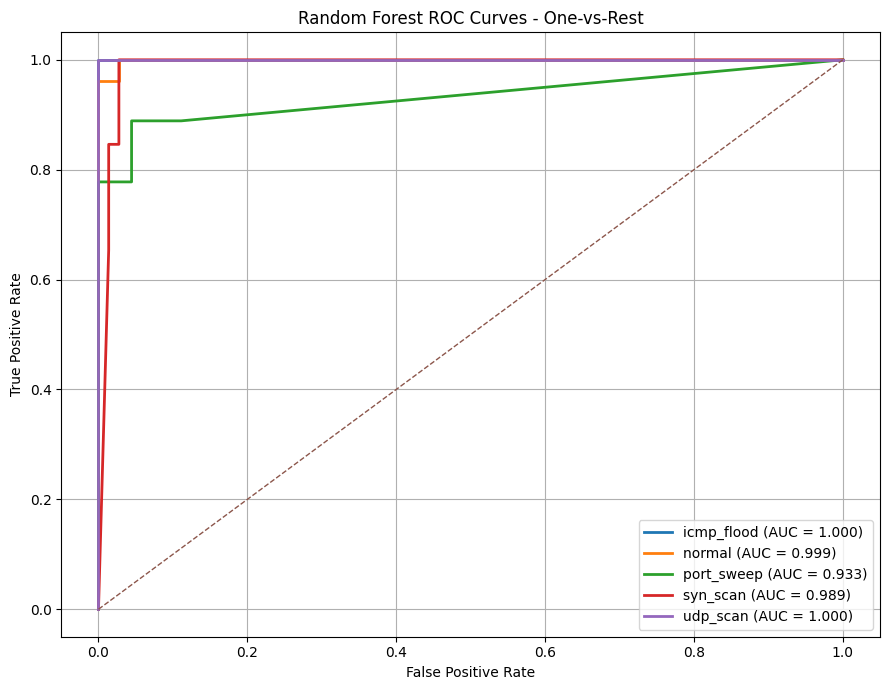

Saved: /home/angel/projects/CNC_Project/reports/figures/rf_roc_curves_ovr.png


,auc_roc
icmp_flood,1.0000
normal,0.9989
port_sweep,0.9333
syn_scan,0.9887
udp_scan,1.0000


In [16]:
## ROC curves one-vs-rest

y_test_binarized = label_binarize(
    y_test,
    classes=np.arange(len(target_names))
)

y_score = rf_model.predict_proba(X_test)

roc_data = {}

plt.figure(figsize=(9, 7))

for i, class_name in enumerate(target_names):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    roc_data[class_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc_auc
    }

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_name} (AUC = {roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curves - One-vs-Rest")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()

plt.savefig(ROC_CURVES_PATH, dpi=300)
plt.show()

print("Saved:", ROC_CURVES_PATH)

auc_scores = {
    class_name: float(roc_data[class_name]["auc"])
    for class_name in target_names
}

auc_df = pd.DataFrame.from_dict(
    auc_scores,
    orient="index",
    columns=["auc_roc"]
).sort_index()

display(auc_df.round(4))

In [17]:
## Random Forest vs Decision Tree

decision_tree = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

decision_tree.fit(X_train, y_train)

dt_train_pred = decision_tree.predict(X_train)
dt_test_pred = decision_tree.predict(X_test)

dt_train_accuracy = accuracy_score(y_train, dt_train_pred)
dt_test_accuracy = accuracy_score(y_test, dt_test_pred)
dt_accuracy_gap = dt_train_accuracy - dt_test_accuracy

dt_report_dict = classification_report(
    y_test,
    dt_test_pred,
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

rf_weighted_f1 = report_dict["weighted avg"]["f1-score"]
dt_weighted_f1 = dt_report_dict["weighted avg"]["f1-score"]

comparison_df = pd.DataFrame([
    {
        "model": "Random Forest",
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "accuracy_gap": accuracy_gap,
        "weighted_f1": rf_weighted_f1
    },
    {
        "model": "Decision Tree",
        "train_accuracy": dt_train_accuracy,
        "test_accuracy": dt_test_accuracy,
        "accuracy_gap": dt_accuracy_gap,
        "weighted_f1": dt_weighted_f1
    }
])

display(comparison_df.round(4))

,model,train_accuracy,test_accuracy,accuracy_gap,weighted_f1
0,Random Forest,0.9796,0.9697,0.0099,0.9689
1,Decision Tree,0.9796,0.9293,0.0503,0.9330


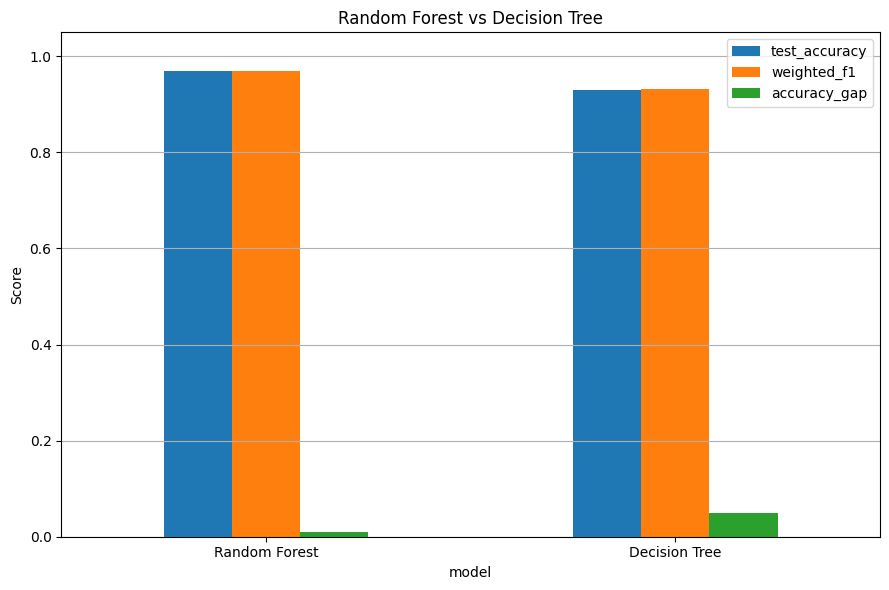

Saved: /home/angel/projects/CNC_Project/reports/figures/rf_vs_decision_tree_comparison.png


In [18]:
## Model comparison plot

plot_df = comparison_df.set_index("model")[[
    "test_accuracy",
    "weighted_f1",
    "accuracy_gap"
]]

ax = plot_df.plot(kind="bar", figsize=(9, 6))

plt.title("Random Forest vs Decision Tree")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()

plt.savefig(MODEL_COMPARISON_PATH, dpi=300)
plt.show()

print("Saved:", MODEL_COMPARISON_PATH)

In [19]:
## Security-oriented false negatives

attack_labels = [
    label for label in target_names
    if label != "normal"
]

security_errors = []

for attack_label in attack_labels:
    attack_mask = test_results["true_label"] == attack_label
    attack_total = int(attack_mask.sum())

    false_negatives_as_normal = int(
        (
            attack_mask &
            (test_results["predicted_label"] == "normal")
        ).sum()
    )

    total_attack_misclassified = int(
        (
            attack_mask &
            (test_results["predicted_label"] != attack_label)
        ).sum()
    )

    security_errors.append({
        "attack_class": attack_label,
        "test_samples": attack_total,
        "total_misclassified": total_attack_misclassified,
        "misclassified_as_normal": false_negatives_as_normal,
        "security_risk": "high" if false_negatives_as_normal > 0 else "low"
    })

security_errors_df = pd.DataFrame(security_errors)

display(security_errors_df)

,attack_class,test_samples,total_misclassified,misclassified_as_normal,security_risk
0,icmp_flood,12,0,0,low
1,port_sweep,9,2,0,low
2,syn_scan,26,0,0,low
3,udp_scan,26,0,0,low


In [20]:
## Generate model evaluation document

lines = []

lines.append("# Complete Model Evaluation\n")

lines.append("## Evaluation setup\n")
lines.append("- Model evaluated: `RandomForestClassifier(n_estimators=100, random_state=42)`\n")
lines.append("- Dataset: `data/processed/dataset_scaled.csv`\n")
lines.append("- Evaluation split: 80/20 stratified train/test split\n")
lines.append("- Cross-validation: 5-fold StratifiedKFold\n")
lines.append("- Classes: `" + "`, `".join(target_names) + "`\n")

lines.append("## Dataset distribution\n")
lines.append(label_distribution.to_markdown())
lines.append("\n")

lines.append("## Train/test distribution\n")
lines.append(split_distribution.to_markdown())
lines.append("\n")

lines.append("## Train vs test accuracy\n")
lines.append(f"- Train accuracy: `{train_accuracy:.4f}`\n")
lines.append(f"- Test accuracy: `{test_accuracy:.4f}`\n")
lines.append(f"- Accuracy gap: `{accuracy_gap:.4f}`\n")

if accuracy_gap > 0.05:
    lines.append(
        "The train-test gap is higher than 5%, which suggests possible overfitting. "
        "A future optimization step should test constraints such as `max_depth`, "
        "`min_samples_split` and `min_samples_leaf`.\n"
    )
else:
    lines.append(
        "The train-test gap is below 5%, so there is no strong evidence of overfitting "
        "in the current split.\n"
    )

lines.append("## Per-class metrics\n")
lines.append(per_class_df.round(4).to_markdown())
lines.append("\n")

lines.append("## Confusion matrix\n")
lines.append(f"- Absolute confusion matrix: `{CONFUSION_MATRIX_EVAL_PATH.relative_to(PROJECT_ROOT)}`\n")
lines.append(f"- Normalized confusion matrix: `{CONFUSION_MATRIX_NORMALIZED_PATH.relative_to(PROJECT_ROOT)}`\n")
lines.append("\nAbsolute confusion matrix:\n")
lines.append(cm_df.to_markdown())
lines.append("\n")

lines.append("## Confusion analysis\n")
if len(confusion_pairs) > 0:
    lines.append(confusion_pairs.to_markdown(index=False))
    lines.append("\n")
else:
    lines.append("The model produced no misclassifications on the test split.\n")

lines.append(
    "From a network security perspective, false negatives where attack traffic is classified "
    "as `normal` are the most relevant errors. Confusions between two attack classes are less "
    "critical operationally, although they still indicate that the model has difficulty separating "
    "similar scanning patterns.\n"
)

lines.append("## Security-oriented false negatives\n")
lines.append(security_errors_df.to_markdown(index=False))
lines.append("\n")

lines.append("## Cross-validation\n")
lines.append(f"- F1 weighted scores: `{np.round(cv_f1_weighted_scores, 4).tolist()}`\n")
lines.append(f"- Mean F1 weighted: `{cv_f1_weighted_scores.mean():.4f}`\n")
lines.append(f"- Std F1 weighted: `{cv_f1_weighted_scores.std():.4f}`\n")
lines.append(f"- Accuracy scores: `{np.round(cv_accuracy_scores, 4).tolist()}`\n")
lines.append(f"- Mean accuracy: `{cv_accuracy_scores.mean():.4f}`\n")
lines.append(f"- Std accuracy: `{cv_accuracy_scores.std():.4f}`\n")

lines.append(
    "The cross-validation results show that the model is stable across folds. "
    "The mean weighted F1-score is above 0.96 and the standard deviation is below 0.02, "
    "which indicates excellent and consistent performance despite the moderate class imbalance.\n"
)

lines.append("## ROC-AUC one-vs-rest\n")
lines.append(f"ROC figure: `{ROC_CURVES_PATH.relative_to(PROJECT_ROOT)}`\n")
lines.append(auc_df.round(4).to_markdown())
lines.append("\n")

lines.append("## Random Forest vs Decision Tree\n")
lines.append(comparison_df.round(4).to_markdown(index=False))
lines.append("\n")
lines.append(f"Comparison figure: `{MODEL_COMPARISON_PATH.relative_to(PROJECT_ROOT)}`\n")

lines.append("## Technical interpretation\n")
lines.append(
    "The Random Forest model performs well because the selected L3/L4 features capture "
    "clear protocol-level differences between the traffic classes. UDP scans are separated "
    "by protocol and by the absence of TCP flags. ICMP flood traffic is characterized by "
    "short, simple flows without TCP state. SYN scan traffic is influenced by TCP control "
    "behavior such as reset packets and low-volume handshakes. Normal traffic tends to show "
    "more regular bidirectional exchange and different byte/packet-size distributions.\n"
)

lines.append("## Error analysis and protocol-level explanation\n")
if len(confusion_pairs) > 0:
    lines.append(
        "The remaining errors are mainly caused by traffic classes that share similar flow-level "
        "statistics. This is expected for short scans or sweep-like traffic, because individual flows "
        "can look similar to normal short request-response traffic when only per-flow L3/L4 metadata "
        "is used.\n"
    )
else:
    lines.append(
        "No errors were observed in the test split. However, this result should be interpreted with "
        "caution because the dataset was generated in a controlled Docker environment. Additional "
        "evaluation with unseen PCAPs is still required.\n"
    )

lines.append("## Limitations and improvements\n")
lines.append(
    "The main limitation is that some scanning behaviors, especially `port_sweep`, can look "
    "similar to normal short request-response flows when each flow is analyzed in isolation. "
    "A concrete improvement would be to add temporal aggregation features such as "
    "`unique_dst_ports_per_src`, `unique_dst_hosts_per_src`, `new_connection_rate` and "
    "`dst_port_entropy` over sliding windows. These features would capture scanning strategy "
    "more directly than per-flow statistics alone.\n"
)

MODEL_EVALUATION_DOC_PATH.write_text("\n".join(lines), encoding="utf-8")

print("Saved:", MODEL_EVALUATION_DOC_PATH)

Saved: /home/angel/projects/CNC_Project/docs/model_evaluation.md


In [21]:
## Save evaluation metrics as JSON

evaluation_metrics = {
    "model": "RandomForestClassifier",
    "random_state": RANDOM_STATE,
    "train_accuracy": float(train_accuracy),
    "test_accuracy": float(test_accuracy),
    "accuracy_gap": float(accuracy_gap),
    "classification_report": report_dict,
    "confusion_matrix": cm_df.to_dict(),
    "normalized_confusion_matrix": cm_normalized_df.to_dict(),
    "confusion_pairs": confusion_pairs.to_dict(orient="records"),
    "false_negatives_by_class": false_negatives_by_class.to_dict(orient="records"),
    "security_errors": security_errors_df.to_dict(orient="records"),
    "cross_validation": {
        "f1_weighted_scores": cv_f1_weighted_scores.tolist(),
        "f1_weighted_mean": float(cv_f1_weighted_scores.mean()),
        "f1_weighted_std": float(cv_f1_weighted_scores.std()),
        "accuracy_scores": cv_accuracy_scores.tolist(),
        "accuracy_mean": float(cv_accuracy_scores.mean()),
        "accuracy_std": float(cv_accuracy_scores.std())
    },
    "roc_auc_ovr": auc_scores,
    "model_comparison": comparison_df.to_dict(orient="records")
}

with MODEL_EVALUATION_JSON_PATH.open("w", encoding="utf-8") as f:
    json.dump(evaluation_metrics, f, indent=2)

print("Saved:", MODEL_EVALUATION_JSON_PATH)

Saved: /home/angel/projects/CNC_Project/docs/model_evaluation_metrics.json
